In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [2]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 10)

In [3]:
samples_df, cns_df = cdu.main_load("3MB")

In [4]:
cns_df = cns.group_samples(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC")))

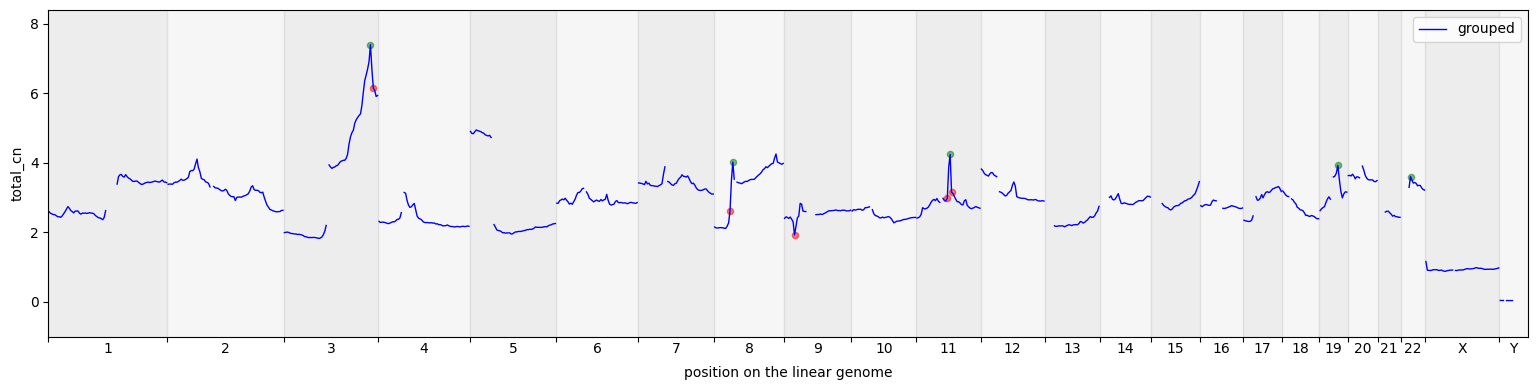

In [5]:
cns_df["score"] = cns.calc_angles(cns_df, "total_cn")

feature = "score"
val_count = 5
sorted_pos = np.argsort(cns_df[feature])
# indices of top 5 values
top_vals = sorted_pos[:val_count]
bot_vals = sorted_pos[-val_count:]

fig, ax = cns.fig_lines( cns_df, cn_columns="total_cn")
cns_df = cns.add_cum_mid(cns_df)

ax.scatter(cns_df["cum_mid"].iloc[top_vals], cns_df["total_cn"].iloc[top_vals], color='red', alpha=0.5, s=20)
ax.scatter(cns_df["cum_mid"].iloc[bot_vals], cns_df["total_cn"].iloc[bot_vals], color='green', alpha=0.5, s=20)

In [6]:
segs = cdu.load_COSMIC()

In [7]:
scores_df = cns.mean_value_per_seg(cns_df, segs, "score").merge(cns.mean_value_per_seg(cns_df, segs, "total_cn"), on=["chrom", "start", "end", "name"])
scores_df["abs_score"] = scores_df["score"].abs()
scores_df["cum_mid"] = cns.calc_cum_mid(scores_df)
scores_df = scores_df.sort_values("abs_score", ascending=False)
print(scores_df.head(10))

     chrom      start        end    name      score  total_cn  abs_score  \
115  chr11   71713909   71791739   NUMA1  67.720495  4.246533  67.720495   
114  chr11   70049268   70053496    FADD  67.720495  4.246533  67.720495   
482   chr3  181429713  181432221    SOX2  60.896450  7.400855  60.896450   
621   chr8   38268655   38326352   FGFR1  54.008706  4.026116  54.008706   
112  chr11   65265232   65273940  MALAT1 -36.888830  2.989666  36.888830   
111  chr11   64570981   64578766    MEN1 -36.888830  2.989666  36.888830   
656   chr9   21967750   21995300  CDKN2A -33.840718  1.928908  33.840718   
488   chr3  187871071  188608460     LPP -23.953360  6.161065  23.953360   
487   chr3  187439164  187463515    BCL6 -23.953360  6.161065  23.953360   
486   chr3  186500993  186507689  EIF4A2 -23.953360  6.161065  23.953360   

        cum_mid  
115  1887660714  
114  1885959272  
482   673880961  
621  1431093193  
112  1881177476  
111  1880482763  
656  1561141237  
488   680689759  
4

Text(0.5, 1.0, 'Top 2 genes with highest absolute change score on chr3 in LUSC')

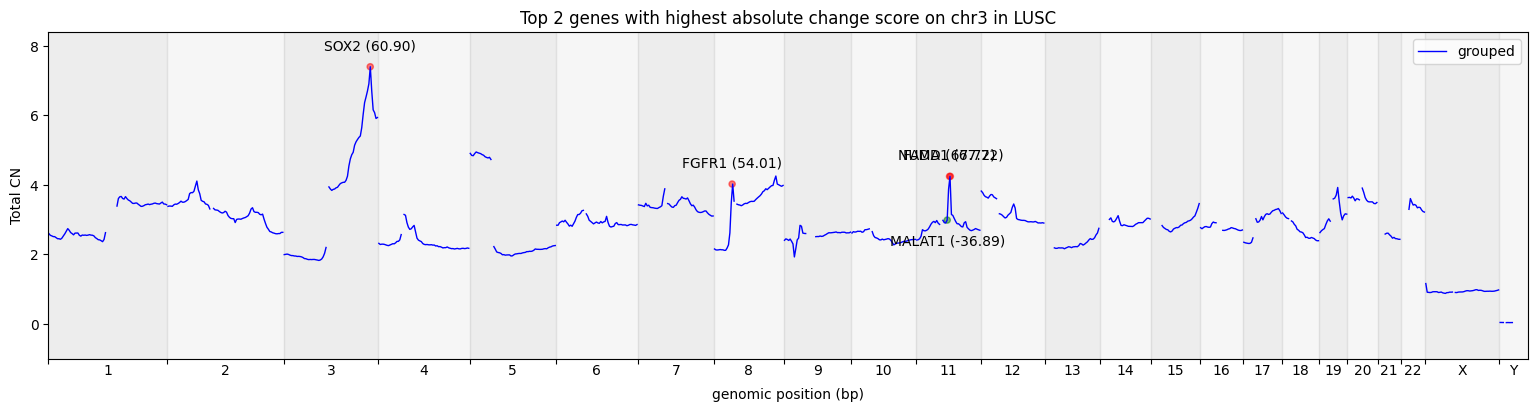

In [8]:
fig, ax = cns.fig_lines(cns_df, cn_columns="total_cn")

# scatter plot of top 5 values in scores_df, use red is score is positive, blue if negative
top_count = 5
top_genes = scores_df.head(top_count)
colors = ["red" if score > 0 else "green" for score in top_genes["score"]]
ax.scatter(top_genes["cum_mid"], top_genes["total_cn"], color=colors, alpha=0.5, s=20)

for i, row in top_genes.iterrows():
	offset = .6 * (-1 if row["score"] > 0 else 1)
	ax.text(row["cum_mid"], row["total_cn"] - offset, f'{row["name"]} ({row["score"]:.2f})', fontsize=10, ha="center", va="center")

ax.set_ylabel("Total CN")
ax.set_xlabel("genomic position (bp)")
ax.set_title("Top 2 genes with highest absolute change score on chr3 in LUSC")